# Improved Semi-Supervised Learning with PyTorch (KMeans + KNN)
### Student id: C00313459
### Name: Amisha Das

## 1. Introduction

This model is an attempt at a semi-supervised learning model (SSL) combining the supervised K Nearest Neighbour (KNN) and unsupervised K-Means models. 

This notebook is a revised and improved version of a previous attempt (submitted in the preliminary submission) which can be found [here](https://github.com/avid00/ml-portoflio1/tree/draft_new/K-means%20and%20KNN%20(SSL)).

### 1.1. Goal
Improving SSL accuracy on SDSS data by addressing outliers, improving clustering, and filtering noise.

### 1.2. Data Understanding

In [1]:
import pandas as pd
import torch
import numpy as np
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('sdss_star_classification.csv')
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['class'])
df.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID,label
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171,0
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427,0
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299,0
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775,0
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842,0


#### **About the Data**
Sloan Digital Sky Survey (SDSS) is a sky survey that collects magnitude values in 5 bands (u,g,r,i and z) and redshift values for stars, quasars and galaxies.

In [13]:
aboutdata = pd.read_csv(
    "C:/Users/mishu/Desktop/study/Sem 2/doyle/SDSS Data Explanation.csv",
    encoding="latin1"
)
pd.set_option('display.max_colwidth', None)

aboutdata

,Column,Description
0,obj_ID,Unique object identifier from SDSS
1,alpha,Right Ascension (RA) in degrees Ñ celestial longitude
2,delta,Declination (DEC) in degrees Ñ celestial latitude
3,"u, g, r, i, z",Magnitudes in five photometric bands (ultraviolet to near-infrared)
4,run_ID,Identifier for the SDSS imaging run
5,rerun_ID,Processing version of the imaging data
6,cam_col,Camera column used during image capture
7,field_ID,ID of the imaging field in which the object appears
8,spec_obj_ID,Unique identifier for the object's spectroscopic observation
9,class,"The actual object classification (GALAXY, STAR, QSO, etc.)"


## 2. Data Preparation (RobustScaler)

In [ ]:
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

In [ ]:
scaler = RobustScaler()
X_np = scaler.fit_transform(df[['u', 'g', 'r', 'i', 'z']])
X = torch.tensor(X_np, dtype=torch.float32)
y = torch.tensor(df['label'].values, dtype=torch.long)

X_labeled, X_unlabeled, y_labeled, y_unlabeled_true = train_test_split(
    X, y, test_size=0.7, stratify=y, random_state=42
)

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [2]:
X_labeled, X_unlabeled = X_labeled.to(device), X_unlabeled.to(device)
y_labeled, y_unlabeled_true = y_labeled.to(device), y_unlabeled_true.to(device)

## 3. Improved KMeans (PyTorch) with Outlier Filtering

Improved KMeans with confidence-based filtering


In [ ]:
def kmeans_torch(X, num_clusters=3, num_iters=100):
    centroids = X[torch.randperm(X.size(0))[:num_clusters]]
    for _ in range(num_iters):
        dists = torch.cdist(X, centroids)
        labels = torch.argmin(dists, dim=1)
        for i in range(num_clusters):
            if (labels == i).sum() > 0:
                centroids[i] = X[labels == i].mean(dim=0)
    return labels, centroids

In [ ]:
# running KMeans
pseudo_labels, centroids = kmeans_torch(X_unlabeled, num_clusters=len(torch.unique(y)))

Confidence: using distance to assigned centroid

Setting a distance threshold by keeping lowest 25% of distances

In [ ]:
with torch.no_grad():
    distances = torch.cdist(X_unlabeled, centroids)
    assigned_centroid_dist = distances[torch.arange(len(pseudo_labels)), pseudo_labels]

In [ ]:

threshold = torch.quantile(assigned_centroid_dist, 0.25)
confident_mask = assigned_centroid_dist <= threshold

In [3]:
# filtering high-confidence pseudo-labeled samples
X_unlabeled_filtered = X_unlabeled[confident_mask]
y_unlabeled_pseudo = pseudo_labels[confident_mask]

In [4]:
# Filter out pseudo-labels from clusters with <50 samples
# valid_clusters = torch.nonzero(cluster_sizes >= 50).squeeze()
# mask = torch.isin(pseudo_labels, valid_clusters)
# X_unlabeled_filtered = X_unlabeled[mask]
# y_unlabeled_pseudo = pseudo_labels[mask]

### 3.1. Combining Labeled + Filtered Pseudo-labeled Data

In [5]:
X_combined = torch.cat([X_labeled, X_unlabeled_filtered], dim=0)
y_combined = torch.cat([y_labeled, y_unlabeled_pseudo], dim=0)

### 3.2. KNN with Mini-Batch Distance Computation

In [6]:
def knn_predict_batched(X_train, y_train, X_test, k=5, batch_size=1000):
    preds = []
    for i in range(0, X_test.size(0), batch_size):
        batch = X_test[i:i+batch_size]
        dists = torch.cdist(batch, X_train)
        knn_idxs = torch.topk(dists, k, largest=False).indices
        knn_labels = y_train[knn_idxs]
        batch_preds, _ = torch.mode(knn_labels, dim=1)
        preds.append(batch_preds)
    return torch.cat(preds)

y_knn_pred = knn_predict_batched(X_combined, y_combined, X_unlabeled, k=5)

## 4. Evaluation

In [ ]:
from sklearn.metrics import classification_report, accuracy_score


In [7]:
y_pred_cpu = y_knn_pred.cpu().numpy()
y_true_cpu = y_unlabeled_true.cpu().numpy()
print("Accuracy:", accuracy_score(y_true_cpu, y_pred_cpu))
print(classification_report(y_true_cpu, y_pred_cpu))

Accuracy: 0.7488571428571429
              precision    recall  f1-score   support

           0       0.85      0.79      0.82     41611
           1       0.80      0.76      0.78     13273
           2       0.50      0.63      0.56     15116

    accuracy                           0.75     70000
   macro avg       0.72      0.73      0.72     70000
weighted avg       0.77      0.75      0.76     70000



Model's accuracy is at 74%

#### Saving Model for Exporting

In [9]:
torch.save({
    'centroids': centroids,
    'X_train': X_combined,
    'y_train': y_combined
}, 'improved_ssl_model.pt')

## 5. PCA Visualisation

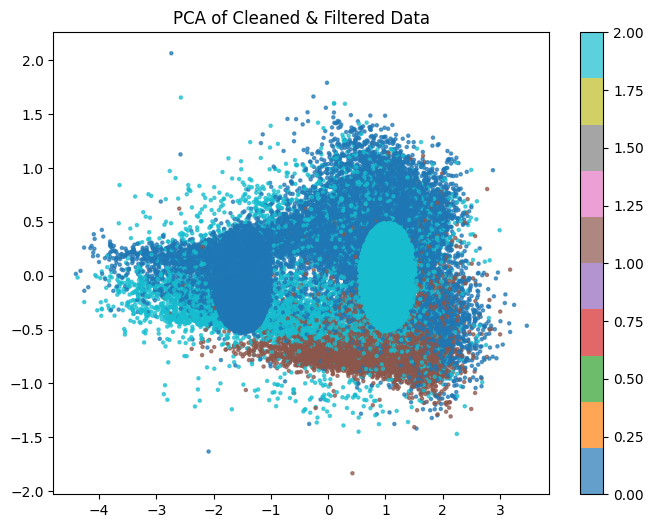

In [11]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Convert to numpy
X_cpu = X_combined.cpu().numpy()
y_cpu = y_combined.cpu().numpy()

# Clip extreme outliers using IQR (Interquartile Range)
Q1 = np.percentile(X_cpu, 25, axis=0)
Q3 = np.percentile(X_cpu, 75, axis=0)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Mask out rows with extreme outliers
mask = np.all((X_cpu >= lower) & (X_cpu <= upper), axis=1)
X_cleaned = X_cpu[mask]
y_cleaned = y_cpu[mask]

# PCA & Plot
X_pca = PCA(n_components=2).fit_transform(X_cleaned)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_cleaned, cmap='tab10', s=5, alpha=0.7)
plt.title("PCA of Cleaned & Filtered Data")
plt.colorbar()
plt.show()


## 6. Log

In [1]:
import pandas as pd


In [14]:
log = pd.read_csv("SSL_Final_Log.csv")
pd.set_option('display.max_colwidth', None)
log

,Model,Description,Level of Difficulty,Time Spent (mins),Change From,Changed To,Old Code,New Code
0,KNN,"Imported mean_absolute_error, mean_squared_error",Easy,10.0,NaN,Added imports for error measurement,NaN,NaN
1,KNN,Used StandardScaler for feature normalization,Medium,15.0,NaN,Applied StandardScaler to dataset,NaN,NaN
2,Data,Split data into labeled and unlabeled,Medium,20.0,No unlabeled data available,Manually removed labels from some data,NaN,NaN
3,K-Means,"Standardized features, chose k=5 for K-Means",Medium,30.0,NaN,Set k=5 for initial testing,NaN,NaN
4,KNN,Trained KNN on labeled dataset,Hard,40.0,NaN,KNN trained using labeled subset,NaN,NaN
5,Preprocessing,Switched from StandardScaler to RobustScaler to handle outliers,Easy,10.0,StandardScaler (mean/std based),RobustScaler (median/IQR based),scaler = StandardScaler()\nX_scaled = scaler.fit_transform(X),"scaler = RobustScaler()\nX_np = scaler.fit_transform(df[['u', 'g', 'r', 'i', 'z']])"
6,Data Preparation,Simulated unlabeled data by hiding 70% of the labels,Medium,20.0,Fully labeled dataset,70% of labels removed (simulated unlabeled),N/A (used all labels),"train_test_split(X, y, test_size=0.7, stratify=y)"
7,KMeans,Implemented custom KMeans in PyTorch for GPU usage,Hard,45.0,sklearn.cluster.KMeans,Custom torch-based KMeans loop,from sklearn.cluster import KMeans\nkmeans = KMeans(n_clusters=3).fit(X),"def kmeans_torch(X, ...):\n centroids = ...\n for _ in range(...): ..."
8,KMeans,Filtered pseudo-labels by confidence using centroid distance threshold,Hard,30.0,Cluster size filtering only,Top 25% most confident points kept,valid_clusters = cluster_sizes >= 50,assigned_dist = cdist(...)\nthreshold = quantile(...)\nmask = dist <= threshold
9,KNN,Replaced full-matrix cdist with mini-batch processing to fix OOM error,Medium,30.0,torch.cdist on entire test set,torch.cdist on batches (batch_size=1000),"dists = torch.cdist(X_test, X_train)","for batch in X_test:\n dists = torch.cdist(batch, X_train)"


## 7. Conclusion

SDSS Data had objects classified (labeleld) into 'star','quasar' and 'galaxy'. I ignored the labels of 70% of the data for training. This then simulated unlabeled data by generating pseudo-labels through custom pytorch-based KMeans and then trained a KNN classification model with confidence-based filtering. 

The final model was used to achieve classification accuracy of 75%.

This was done through scaling, batch-wise distance computation and PCA visualisation.

## 8. Future Work

1. Increase accuracy
2. Use distances to weigh KNN votes
3. include pseudo-label confidence in training set

### Appendices, Acknowledgments and References

- Sloan Digital Sky Survey (SDSS) — https://www.sdss.org. Dataset: SDSS Star Classification (Photometric + Spectroscopic)
- [KNN(k-nearest neighbor) algorithm as supervised and as unsupervised algorithm. What are the main differences? How can it be both?](https://stats.stackexchange.com/questions/578229/knnk-nearest-neighbor-algorithm-as-supervised-and-as-unsupervised-algorithm-w)
- [Semi supervised Learning Clustering Geo Data](https://www.kaggle.com/code/raisssaid/semi-supervised-learning-clustering-geo-data?utm_source=chatgpt.com)
- ChatGPT for debugging and code 